Importing libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score, accuracy_score
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

warnings.filterwarnings("ignore")

Reading spotify_tracks.csv

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
data = pd.read_csv("/content/drive/MyDrive/spotify_tracks.csv")
data.head()
data.shape

(114000, 21)

# Data Exploration
-Abinaya

In [4]:
#takes a sample of 5000 rows of the data set
data_sample = data.sample(n=5000, random_state=42)

Histograms:

<function matplotlib.pyplot.show(close=None, block=None)>

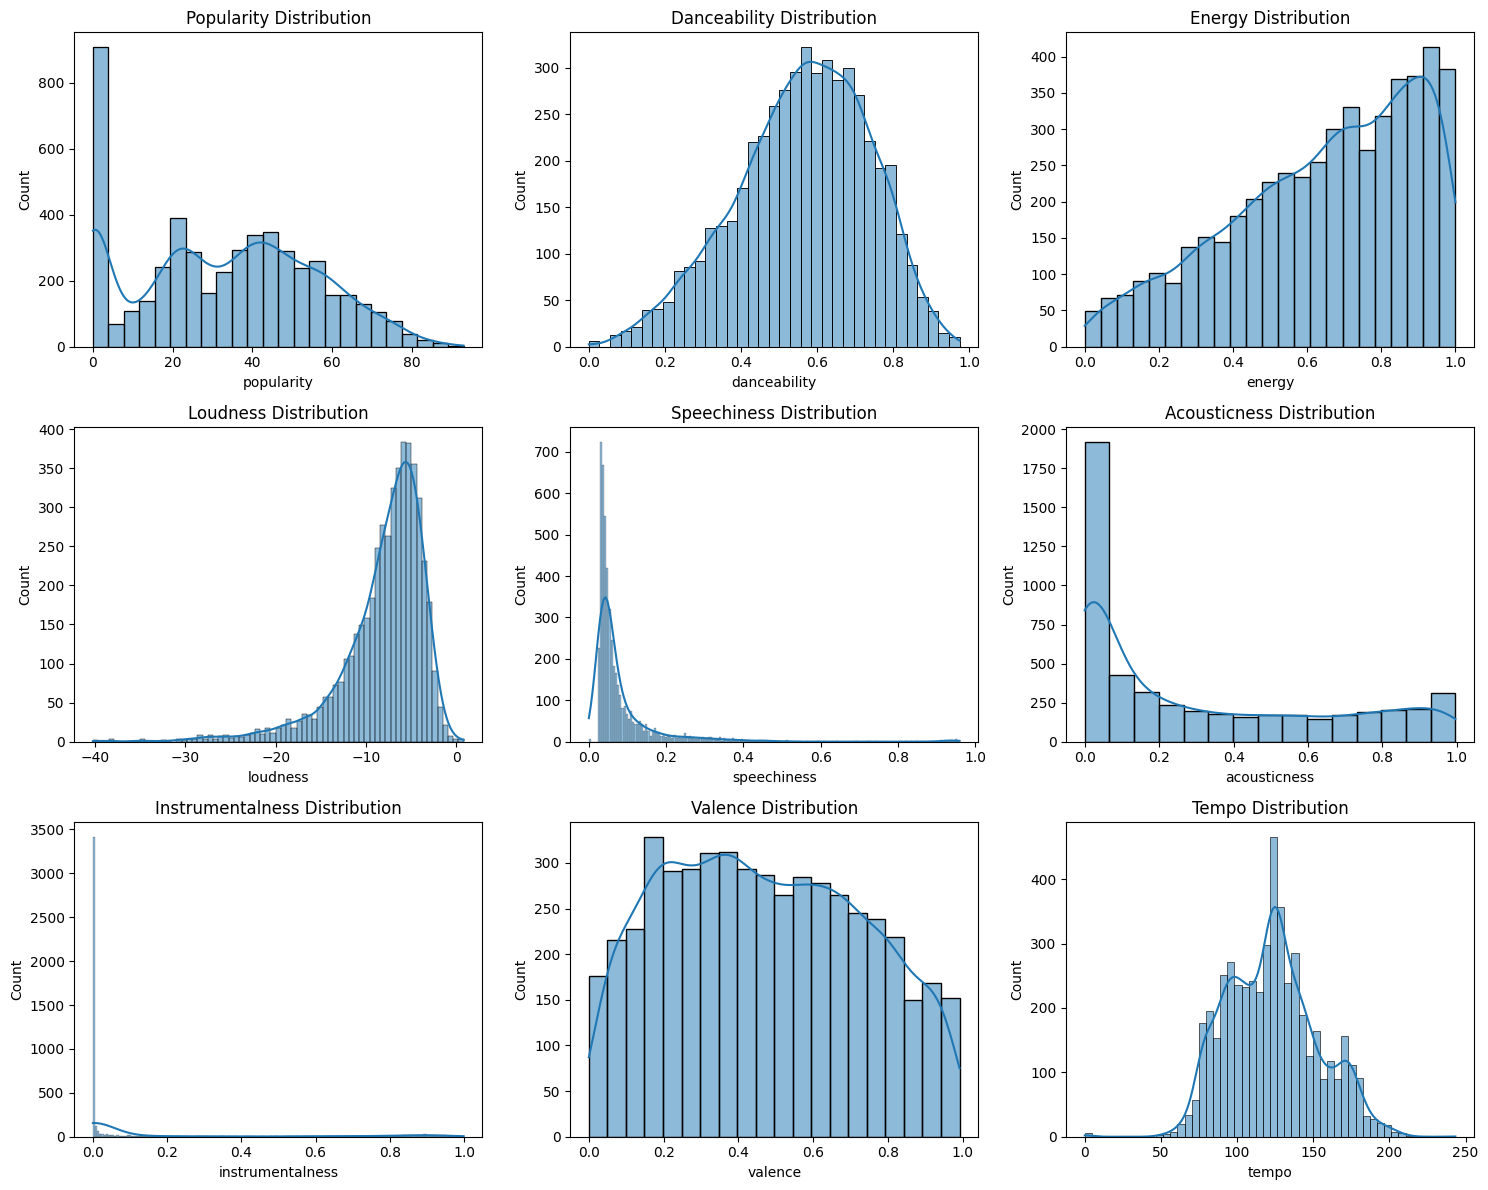

In [5]:
#plotting histograms

#set up a grid of 9 plots
plt.figure(figsize = (15,12))

#1. popularity
plt.subplot(3,3,1)
sns.histplot(data_sample['popularity'], kde=True)
plt.title("Popularity Distribution")

#2. danceability
plt.subplot(3,3,2)
sns.histplot(data_sample['danceability'], kde=True)
plt.title("Danceability Distribution")

#3. energy
plt.subplot(3,3,3)
sns.histplot(data_sample['energy'], kde=True)
plt.title("Energy Distribution")

#4. loudness
plt.subplot(3,3,4)
sns.histplot(data_sample['loudness'], kde=True)
plt.title("Loudness Distribution")

#5. speechiness
plt.subplot(3,3,5)
sns.histplot(data_sample['speechiness'], kde=True)
plt.title("Speechiness Distribution")

#6. acousticness
plt.subplot(3,3,6)
sns.histplot(data_sample['acousticness'], kde=True)
plt.title("Acousticness Distribution")

#7. instrumentalness
plt.subplot(3,3,7)
sns.histplot(data_sample['instrumentalness'], kde=True)
plt.title("Instrumentalness Distribution")

#8. valnce
plt.subplot(3,3,8)
sns.histplot(data_sample['valence'], kde=True)
plt.title("Valence Distribution")

#9. tempo
plt.subplot(3,3,9)
sns.histplot(data_sample['tempo'], kde=True)
plt.title("Tempo Distribution")

#dont overlap
plt.tight_layout()

#show plot
plt.show

Correlation Heatmap

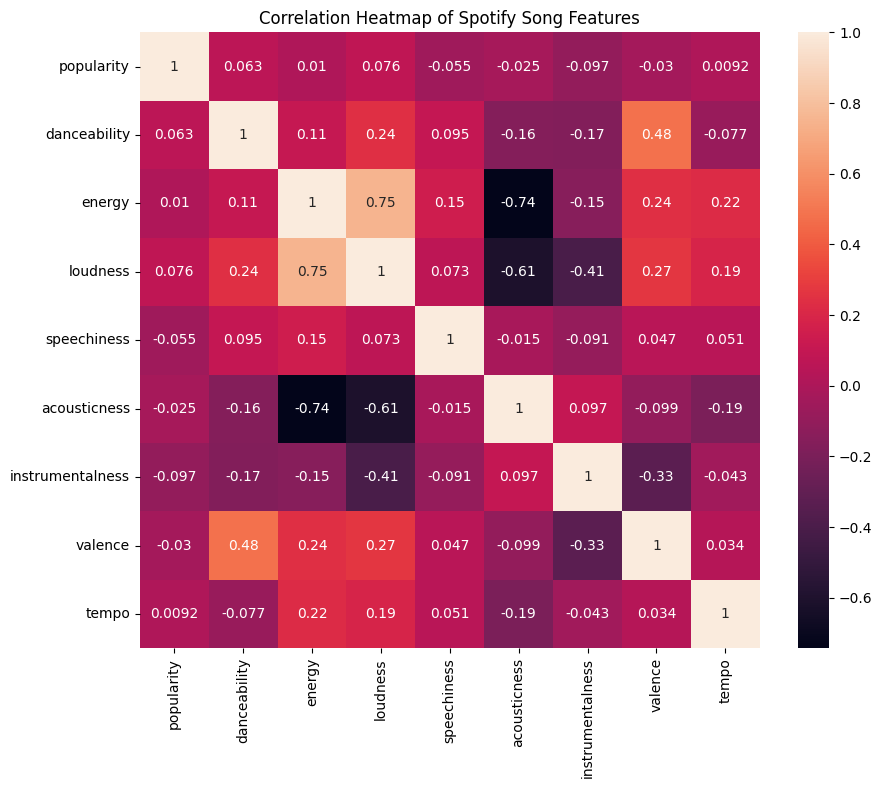

In [6]:
#list of columns to compare
columns_to_compare = ['popularity', 'danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'valence', 'tempo']

#filter sample
data_features = data_sample[columns_to_compare]

#calculate correlation matrix
corr_matrix = data_features.corr()

#plot heatmp
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True)
plt.title("Correlation Heatmap of Spotify Song Features")
plt.show()

Explanation of Findings:
The heatmap shows a strong positive correlation of 0.75 between energy and loudness which means that louder songs almost always have a higher energy. There is a strong negative correlation of -0.74 between energy and acousticness which means that acoustic sounds generaly have a lower energy. Also, danceability and valence have a positive correlation of 0.48 showing that "happier" songs are generally easier to dance to.



Should there be any other variables added based on the entire dataset?

Right now, the reccomender only looks at pure sound numbers, so adding the genre would provide context to the system. This way the system would be less likely to provide a completely wrong style of music just because it mathematically matches.

# Model Enhancement
-Esther

Clean the data first, by removing outliers using the interquartile range. I think this is the best way, because it keeps data that is most clustered together, making the centroids more accurate, rather than being stretched out by the extremes.

In [7]:
features = ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo'] #add features
df_clean = data.copy() #clean the copy

#find the first and third quartile, and subtract them to get the interquartile range
for col in features:
  Q1 = df_clean[col].quantile(0.25)
  Q3 = df_clean[col].quantile(0.75)
  IQR = Q3 - Q1

  #finding the lower and upper bounds, slightly higher and lower than the interquartile range using the 1.5 quartile rule
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  #calculating the clean column
  df_clean[col] = np.clip(df_clean[col], lower_bound, upper_bound)

In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean[features])

#fit and transform using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

sse = []
k_rng = range(1,11)
for k in k_rng:
    km = KMeans(n_clusters=k)
    km.fit(X_pca) #fit on X_pca data
    sse.append(km.inertia_)

Use the elbow test to find the optimal amount of clusters

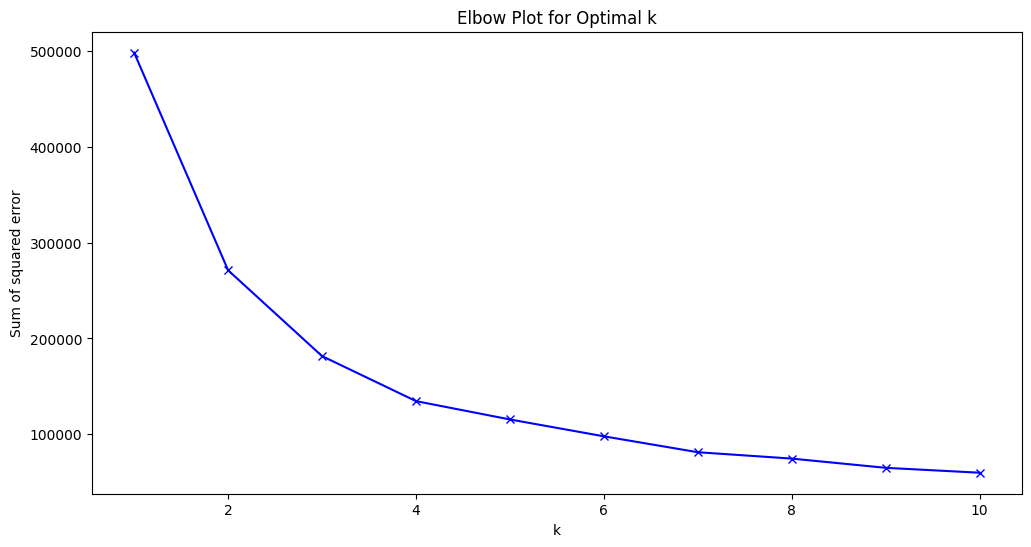

In [9]:
#elbow plot
plt.figure(figsize=(12,6))
plt.plot(k_rng, sse, 'bx-')
plt.xlabel('k')
plt.ylabel('Sum of squared error')
plt.title('Elbow Plot for Optimal k')
plt.show()

It is very similar between 3 and 4, so I used a silhoutte score to find out which number of clusters is better

In [10]:
for k in [3, 4]:
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    print(f"k = {k}, the silhouette score is: {score:.4f}")

k = 3, the silhouette score is: 0.3819
k = 4, the silhouette score is: 0.3766


The silhouette score for k = 4 is higher, so it shows that 4 clusters is the optimum, however, looking at it from a data scientist's perspective, the lowest number of clusters is the optimum, as it allows us to assign labels to each cluster more easily.

Now I am going to be comparing the KMeans clustering method with DBSCAN and Agglomerative clustering, to see which one is better at creating clusters of songs with similar attributes.

KMeans

KMeans silhouette score: 0.3766


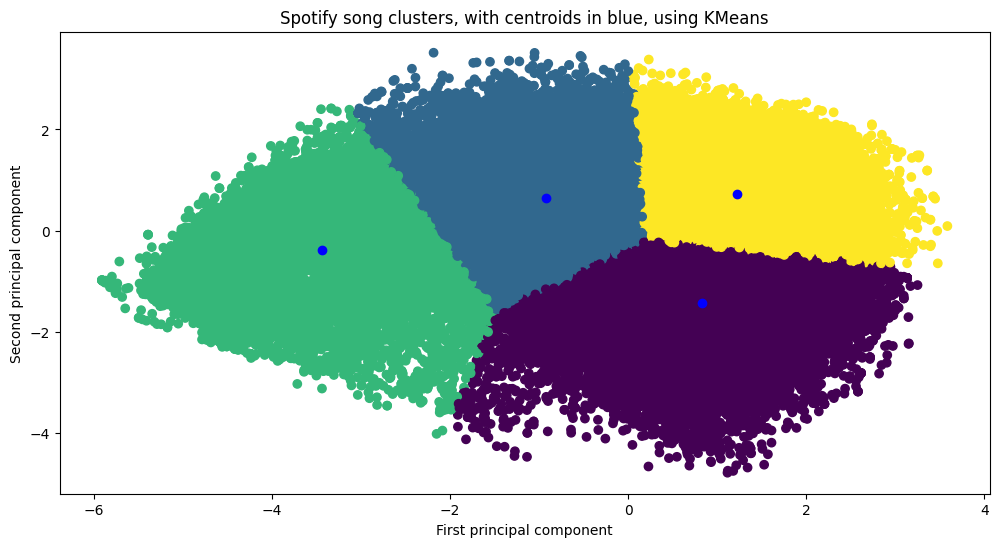

In [11]:

kmeans_model = KMeans(n_clusters = 4, random_state = 42)

kmeans_model.fit(X_pca)

kmeans_labels = kmeans_model.predict(X_pca)

kmeans_sil = silhouette_score(X_pca, kmeans_labels)
print(f"KMeans silhouette score: {kmeans_sil:.4f}")

#plotting KMeans Clusters
plt.figure(figsize=(12,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels)
plt.scatter(kmeans_model.cluster_centers_[:,0], kmeans_model.cluster_centers_[:,1], color='blue') #plot cluster centers
plt.title('Spotify song clusters, with centroids in blue, using KMeans')
plt.xlabel('First principal component')
plt.ylabel('Second principal component')
plt.show()

DBSCAN

I used a random sample of 10,000, otherwise the data starts crashing and giving me an error, saying that I have run out of RAM.

Similarly, using an eps or 0.5 only found 1 cluster, and this isn't helpful. So I changed the eps to 0.25 to find 4 clusters, making it more helpful for analysis.

In [12]:
#making a sample
np.random.seed(42)
sample_indices = np.random.choice(X_pca.shape[0], size=min(10000, X_pca.shape[0]), replace=False)
X_pca_sample = X_pca[sample_indices]

For future reference, I should use stratified sampling instead so that the random samples aren't all from one cluster.

In [13]:
DBSCAN_model = DBSCAN(eps = 0.25, min_samples = 5)

DBSCAN_labels = DBSCAN_model.fit_predict(X_pca_sample)

unique_labels = set(DBSCAN_labels) - {-1}
num_clusters = len(unique_labels)
print(f"Number of clusters: {num_clusters}")

DBSCAN_sil = silhouette_score(X_pca_sample, DBSCAN_labels, random_state = 42)
print(f"DBSCAN silhouette score: {DBSCAN_sil:.4f}")

Number of clusters: 4
DBSCAN silhouette score: 0.2872


Since DBSCAN is density based, there are no centroids on the graph.

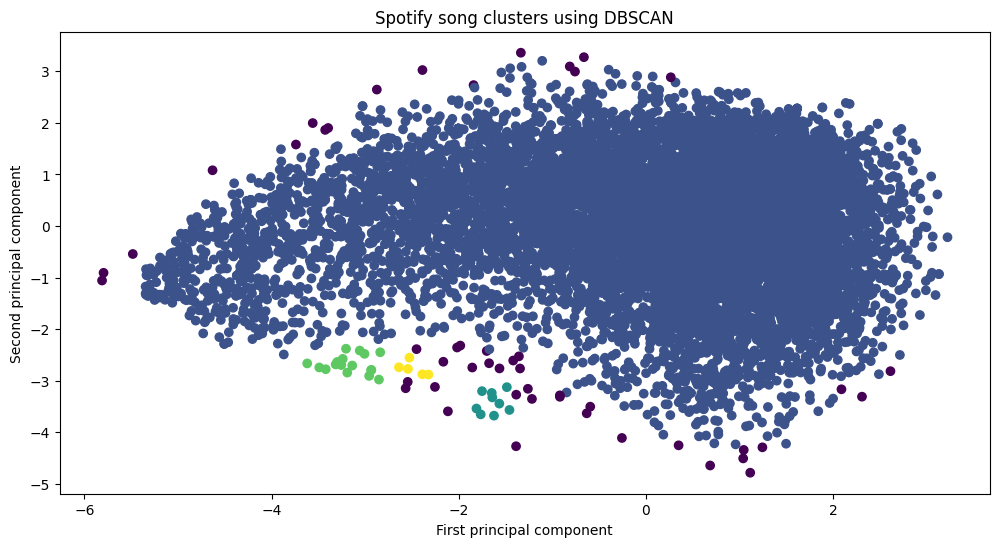

In [14]:
#plotting DBSCAN
plt.figure(figsize=(12,6))
plt.scatter(X_pca_sample[:, 0], X_pca_sample[:, 1], c=DBSCAN_labels)
plt.title('Spotify song clusters using DBSCAN')
plt.xlabel('First principal component')
plt.ylabel('Second principal component')
plt.show()

Agglomerative Clustering

After testing with the full dataset also resulting in crashing, I used the previews sample set to fit this model as well.

In [15]:
agg_model = AgglomerativeClustering(n_clusters = 4)
agg_labels = agg_model.fit_predict(X_pca_sample)

agg_sil = silhouette_score(X_pca_sample, agg_labels)
print(f"Agglomerative Clustering silhouette score: {agg_sil:.4f}")

Agglomerative Clustering silhouette score: 0.2817


Text(0.5, 1.0, 'Spotify song clusters using Agglomerative Clustering')

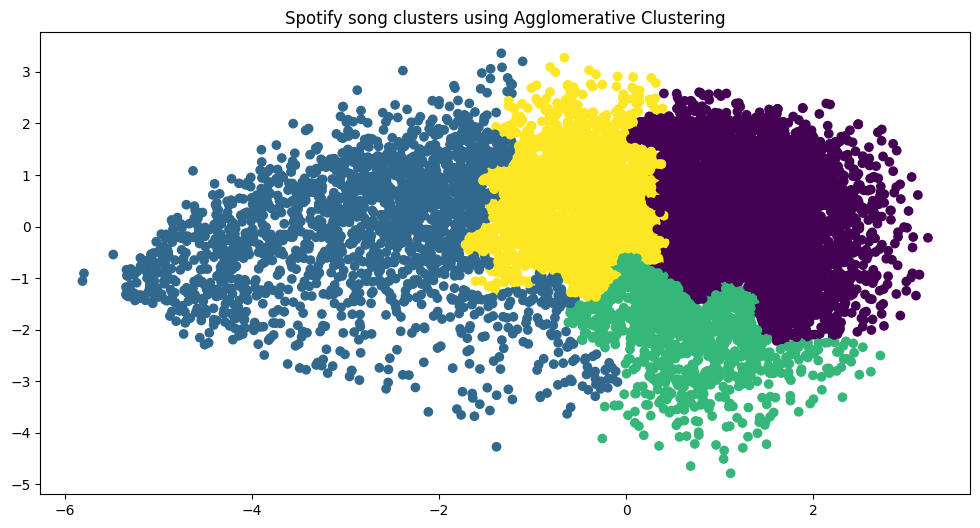

In [16]:
#plot
plt.figure(figsize=(12,6))
plt.scatter(X_pca_sample[:, 0], X_pca_sample[:, 1], c=agg_labels)
plt.title('Spotify song clusters using Agglomerative Clustering')

# Conclusion

First, I removed anomalies with the 1.5 quartile rule, which keeps all values between Q1 - 1.5 * IQR and Q3 + 1.5 * IQR.

Then,

Overall, the model with the highest silhouette score was KMeans, so we will be using that as our primary model.



# User Interaction and Feedback
-Alexander



In [17]:
tempdf = pd.DataFrame({
    'track_name': df_clean['track_name'].values,
    'label': kmeans_labels
})

#Collect favourite songs
userInput = input("enter your favourite songs(seperate by comma):")
favSongs = []
for name in userInput.split(','):
  favSongs.append(name.strip())


enter your favourite songs(seperate by comma):wonderwall, mr brightside


The input string is divided into seperate strings consists of track names and  save them into the favSongs list.

In [18]:
#Recommend 5 songs within the same cluster
userClusters = tempdf[tempdf['track_name'].isin(favSongs)]['label']
sameStyleSongs = tempdf[tempdf['label'].isin(userClusters)]
recSongs = []
for song in sameStyleSongs['track_name']:
  if song not in favSongs and len(recSongs) < 5:
    recSongs.append(song)
print("Recommended Songs:\n")
for song in recSongs:
    print(song,'\n')

Recommended Songs:



By using the KMeans model built before,it recommends five songs within the same cluster categorized by KMeans.

In [19]:
feedback = {}
totalAvg = []
totalScore = 0
if len(recSongs) > 0:
  for song in recSongs:
    score = float(input("Rate" + song + "(From 1 to 5):"))
    feedback[song] = score
    totalScore += score
  avgRating = totalScore / len(recSongs)
  totalAvg.append(avgRating)
else:
  print("No recommended songs")

No recommended songs


This part collects users' rating of five recommended songs, and records it into the totalAvg list each time.

# Innovative Component
-Raime

In [24]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')
data = pd.read_csv("/content/drive/MyDrive/spotify_tracks.csv")
import random
#then adding in a modeling component
#but first more importing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
#spliting up the data (training and testing sets)
X= df_clean[['danceability','energy','loudness']]
y= df_clean['popularity']
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.8, random_state=42)
#making a model based on the data
model=RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

#checking the accuracy of the model (and showing the results)
predictions=model.predict(X_test)
mn=mean_absolute_error(y_test,predictions)
r2=r2_score(y_test, predictions)
print(f"Mean Absolute Error: ${mn:.2f}")
print(f"R-squared: ${r2:.2f}")

#making it give a user a prediction (making it based on user feedback in the previous section + K_means graph)
model.predict(X_test)

#randomizing the song request after getting a list for the user (from the designated list that it created)
randomrec=random.choice(predictions)
print(randomrec)
#making another list of songs that were already reccomended)
previousrec=[]
if randomrec not in previousrec:
  previousrec.append(randomrec)
  print(previousrec)
#making it check in with the user after every 4 recs
if len(previousrec)==4:
  userInput=input("Have we done a good job so far?")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Mean Absolute Error: $15.57
R-squared: $0.19
42.55
[np.float64(42.55)]
